In [2]:
import json
from test import test_model
import torch
from glob import glob
import random
import pandas as pd
from model import Encoder, Decoder
import torch.nn as nn
from monai.inferers import SlidingWindowInferer
import matplotlib.pyplot as plt

mkdir -p failed for path /home/jovyan/.cache/matplotlib: [Errno 13] Permission denied: '/home/jovyan/.cache/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-i8dbfdb8 because there was an issue with the default path (/home/jovyan/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [3]:
import json
from easydict import EasyDict as edict
with open("pipeline_test.json", "r") as f:
    cfg = edict(json.load(f))

In [4]:
roi_size = (96,96,96)
device = 'cuda:0'

enc_path = 'reports/encoder_best.pth'
dec_path = 'reports/decoder_best.pth'
encoder = Encoder(roi_size[0], roi_size[1], roi_size[2], z_dim=512).to(device)
decoder = Decoder(roi_size[0], roi_size[1], roi_size[2], z_dim=512).to(device)

In [5]:
enc_state_dict = torch.load(enc_path, weights_only = True)['encoder']
dec_state_dict = torch.load(dec_path, weights_only = True)['decoder']
encoder.load_state_dict(enc_state_dict)
decoder.load_state_dict(dec_state_dict)

<All keys matched successfully>

In [6]:
from dataset import get_dataloader
train_load, val_load = get_dataloader(cfg, mode = 'train')

total number of images: 100
number of images for training: 80
number of images for validation: 20


In [7]:
# Adicionado 08/01/2026 - teste de sliding window
class AutoEncoderWrapper(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)




model_wrapper = AutoEncoderWrapper(encoder, decoder)
# Use sw_batch_size=1 to be safe with memory
inferer = SlidingWindowInferer(roi_size=(96,96,96), sw_batch_size=1, overlap=0.5, mode = 'gaussian')

In [8]:
for data in val_load:
        img = data['im'].to(cfg.device)
        # ==========forward=========
        break

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [12]:
img.size()

torch.Size([1, 1, 160, 192, 96])

In [9]:
torch.cuda.empty_cache()
with torch.no_grad():
    x_hat = inferer(img, model_wrapper)


In [10]:
numpy_data = img.detach().cpu().squeeze().numpy()

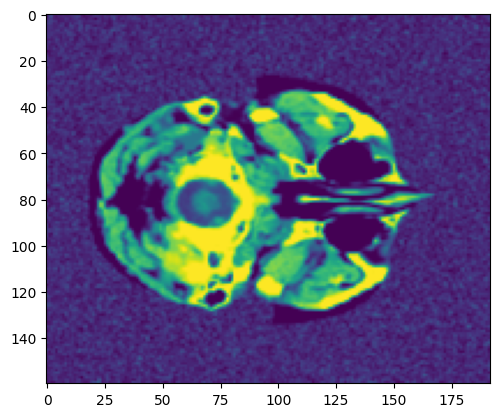

In [11]:
plt.imshow(numpy_data[:,:,20])


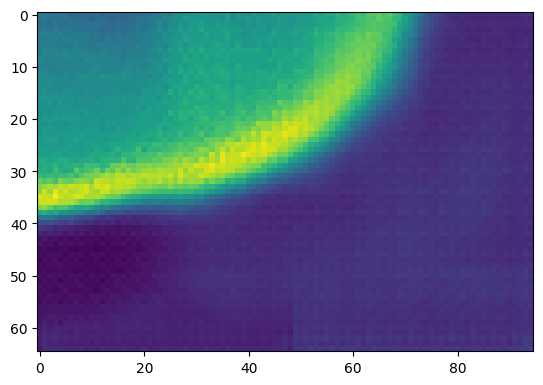

In [14]:
predicted_img = x_hat.detach().cpu().squeeze().numpy()
i = 1
slice = 50
plt.imshow(predicted_img[95*i:95*(i+1),95*i:95*(i+1),slice])


In [21]:
predicted_img.shape

(160, 192, 96)

In [15]:
import nibabel as nib
import numpy as np
import os 
img = nib.Nifti1Image(predicted_img, np.eye(4))  # Save axis for data (just identity)

img.header.get_xyzt_units()
img.to_filename('test_100img_100epochs.nii.gz')  # Save as NiBabel file

In [31]:
img.shape

(512, 512, 277)